# Module 3: Machine Learning Coding Exercise
**Cash Johnson | BUS4 118S**

GitHub repo (all code and datasets): https://github.com/Shacxify/BUS4118S-module3-ml

All four datasets are 100+ record CSVs, AI-generated per the instructor's Module 3 dataset instructions and calibrated to real-world reference points (sources cited in each part's header comment). The notebook loads them straight from the GitHub repo, so it runs top to bottom in Colab with no setup.

In [1]:
# Data loading helper: pull each CSV from the GitHub repo (works in Colab),
# fall back to a local copy if you cloned the repo instead.
import os
import pandas as pd

RAW = 'https://raw.githubusercontent.com/Shacxify/BUS4118S-module3-ml/main/'

def load(csv_name):
    if os.path.exists(csv_name):
        return pd.read_csv(csv_name)
    return pd.read_csv(RAW + csv_name)

## Part 1: House Price Prediction (Linear Regression)

In [2]:
# Part 1: House Price Prediction (Linear Regression)
# Author: Cash Johnson
#
# Data source: house_prices.csv (150 records). AI-generated per the
# instructor's Module 3 dataset instructions, calibrated to San Jose, CA
# metro pricing (Zillow Home Value Index reference points: roughly
# $500+/sq ft downtown, less in suburbs and the rural edges of the metro).
# See generate_datasets.py in this repo for exactly how it was built.
#
# Changes from starter code:
# - Replaced the 10-row hardcoded sample with a 150-row CSV loaded via pandas
# - Added test-set evaluation (R^2) so we know the model generalizes
# - Added plain-language explanations of every coefficient in the output

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load dataset from CSV (module 2 skill: reading files instead of hardcoding data)
df = load('house_prices.csv')
print(f"Loaded {len(df)} records from house_prices.csv\n")

# Features and target
X = df[['square_footage', 'location']]
y = df['price']

# Preprocessing: one-hot encode the categorical 'location' column,
# pass square_footage through unchanged
preprocessor = ColumnTransformer(
    transformers=[('location', OneHotEncoder(sparse_output=False), ['location'])],
    remainder='passthrough')

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Split so we can check performance on houses the model never saw
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

# How well does it generalize?
r2 = r2_score(y_test, model.predict(X_test))
print(f"Test set R^2: {r2:.3f} (share of price variation the model explains)\n")

# Predict a 2000 sq ft house in Downtown
new_house = pd.DataFrame({'square_footage': [2000], 'location': ['Downtown']})
predicted_price = model.predict(new_house)[0]
print(f"Predicted price for a 2000 sq ft house in Downtown: ${predicted_price:,.0f}\n")

# Coefficients, explained in plain language
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
coefs = model.named_steps['regressor'].coef_
print("Model coefficients:")
for name, c in zip(feature_names, coefs):
    print(f"  {name}: {c:,.2f}")

sqft_coef = coefs[list(feature_names).index('remainder__square_footage')]
print(f"""
What the coefficients mean:
- square_footage ({sqft_coef:,.0f}): every extra square foot adds about
  ${sqft_coef:,.0f} to the predicted price, holding location constant.
  Same idea as the "$200 per square foot" example from lecture, just at
  San Jose prices.
- The three location coefficients are premiums/discounts relative to the
  model's baseline. Downtown carries the largest positive effect and Rural
  the largest negative one, so the SAME house is worth more Downtown than
  in a Rural area purely because of where it sits.
""")


Loaded 150 records from house_prices.csv

Test set R^2: 0.948 (share of price variation the model explains)

Predicted price for a 2000 sq ft house in Downtown: $1,255,475

Model coefficients:
  location__location_Downtown: 243,724.46
  location__location_Rural: -264,262.42
  location__location_Suburb: 20,537.96
  remainder__square_footage: 418.78

What the coefficients mean:
- square_footage (419): every extra square foot adds about
  $419 to the predicted price, holding location constant.
  Same idea as the "$200 per square foot" example from lecture, just at
  San Jose prices.
- The three location coefficients are premiums/discounts relative to the
  model's baseline. Downtown carries the largest positive effect and Rural
  the largest negative one, so the SAME house is worth more Downtown than
  in a Rural area purely because of where it sits.



## Part 2: Customer Churn Prediction (Logistic Regression)

In [3]:
# Part 2: Customer Churn Prediction (Logistic Regression)
# Author: Cash Johnson
#
# Data source: customer_churn.csv (200 records). AI-generated per the
# instructor's Module 3 dataset instructions, patterned after the IBM Telco
# Customer Churn dataset on Kaggle
# (kaggle.com/datasets/blastchar/telco-customer-churn).
# See generate_datasets.py in this repo for exactly how it was built.
#
# Changes from starter code:
# - Replaced the 10-row hardcoded sample with a 200-row CSV loaded via pandas
# - Added test-set accuracy so we know the model actually predicts
# - Added coefficient explanations and a business interpretation section

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load dataset from CSV
df = load('customer_churn.csv')
print(f"Loaded {len(df)} records from customer_churn.csv "
      f"({df['churn'].mean():.0%} churned)\n")

num_features = ['age', 'monthly_usage_hours', 'purchase_amount', 'customer_service_calls']
cat_features = ['region']
X = df[num_features + cat_features]
y = df['churn']

# Preprocessing: scale numeric features, one-hot encode region
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(sparse_output=False), cat_features)
])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
model.fit(X_train, y_train)

accuracy = accuracy_score(y_test, model.predict(X_test))
print(f"Test set accuracy: {accuracy:.0%}\n")

# Score a new customer
new_customer = pd.DataFrame({
    'age': [35],
    'monthly_usage_hours': [30.0],
    'purchase_amount': [220.00],
    'customer_service_calls': [3],
    'region': ['West']
})
churn_probability = model.predict_proba(new_customer)[0][1]
threshold = 0.5
at_risk = churn_probability > threshold

print(f"New customer churn probability: {churn_probability:.2f} "
      f"({churn_probability:.0%} chance they leave)")
print(f"Classification at {threshold} threshold: "
      f"{'AT RISK (churn = 1)' if at_risk else 'not at risk (churn = 0)'}\n")

# Coefficients, explained
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
coefs = model.named_steps['classifier'].coef_[0]
print("Model coefficients (positive = pushes toward churn):")
for name, c in zip(feature_names, coefs):
    print(f"  {name}: {c:+.3f}")

print("""
What this means for the business:
- The probability is the model's estimate of how likely this specific
  customer is to leave. A 0.70 means a 70% chance of churn.
- The 0.5 threshold is the cutoff for action: above it we treat the
  customer as at risk, below it we leave them alone.
- Customer service calls carry a strong positive coefficient (more calls,
  more churn risk), while usage hours and purchase amount are negative
  (engaged, paying customers stick around).
- Practical use: score the whole customer base monthly, then point
  retention spend (discounts, a check-in call, a win-back offer) only at
  the customers above the threshold. That is far cheaper than blanket
  offers, since keeping a customer costs less than acquiring a new one.
""")


Loaded 200 records from customer_churn.csv (48% churned)

Test set accuracy: 72%

New customer churn probability: 0.73 (73% chance they leave)
Classification at 0.5 threshold: AT RISK (churn = 1)

Model coefficients (positive = pushes toward churn):
  num__age: -0.216
  num__monthly_usage_hours: -1.787
  num__purchase_amount: -1.244
  num__customer_service_calls: +1.374
  cat__region_East: +0.436
  cat__region_North: -0.152
  cat__region_South: -0.630
  cat__region_West: +0.348

What this means for the business:
- The probability is the model's estimate of how likely this specific
  customer is to leave. A 0.70 means a 70% chance of churn.
- The 0.5 threshold is the cutoff for action: above it we treat the
  customer as at risk, below it we leave them alone.
- Customer service calls carry a strong positive coefficient (more calls,
  more churn risk), while usage hours and purchase amount are negative
  (engaged, paying customers stick around).
- Practical use: score the whole customer 

## Part 3: Customer Segmentation (K-Means)

Loaded 180 records from customer_data.csv



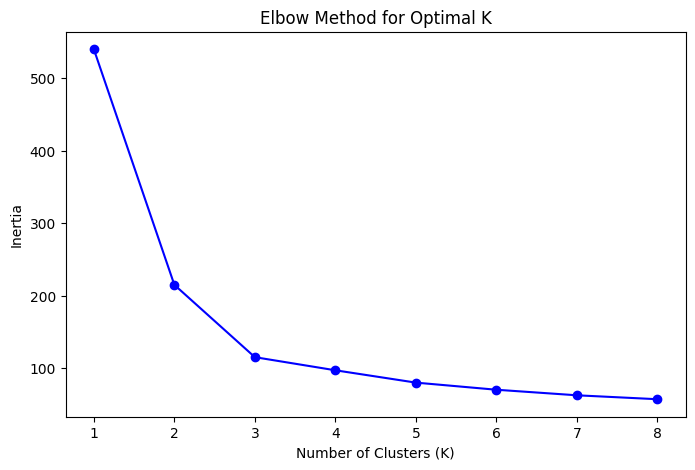

Inertia by K:
  K=1: 540.0
  K=2: 215.1
  K=3: 115.3
  K=4: 97.2
  K=5: 80.2
  K=6: 70.4
  K=7: 62.7
  K=8: 57.3

Chosen K = 3: the inertia curve bends hardest at 3 (big drops from 1->2->3, small drops after). See elbow_plot.png.

Cluster characteristics (averages):
         annual_spending  purchase_frequency    age  customers
cluster                                                       
0                1611.65               21.58  27.98         65
1                 645.66                4.47  52.03         62
2                4181.65               17.58  35.83         53

Targeted strategies:

Cluster 0 (avg spend $1,612, 22 purchases/yr):
  Frequent budget buyers: bundle deals, bulk discounts, or a
  subscription plan to lock in their habit and raise basket size.

Cluster 1 (avg spend $646, 4 purchases/yr):
  Low-engagement customers: personalized re-engagement emails and
  a first-order-back incentive; cheap channels only, low expected LTV.

Cluster 2 (avg spend $4,182, 18 purcha

In [4]:
# Part 3: Customer Segmentation (K-Means Clustering)
# Author: Cash Johnson
#
# Data source: customer_data.csv (180 records). AI-generated per the
# instructor's Module 3 dataset instructions, patterned after the Mall
# Customer Segmentation dataset on Kaggle
# (kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python).
# See generate_datasets.py in this repo for exactly how it was built.
#
# Changes from starter code:
# - Replaced the hardcoded sample with a 180-row CSV loaded via pandas
# - Extended the elbow search to K=1..8 and printed the inertia values
#   so the K choice is justified with numbers, not just a picture
# - Cluster strategies are generated from each cluster's actual averages

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load dataset from CSV
df = load('customer_data.csv')
print(f"Loaded {len(df)} records from customer_data.csv\n")

# Scale the numeric features so no single feature (like spending, which is
# in the thousands) dominates the distance calculation
features = ['annual_spending', 'purchase_frequency', 'age']
X_scaled = StandardScaler().fit_transform(df[features])

# Elbow method: fit K-Means for K=1..8 and track inertia
K_range = range(1, 9)
inertia = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.savefig('elbow_plot.png')
plt.show()

print("Inertia by K:")
for k, i in zip(K_range, inertia):
    print(f"  K={k}: {i:,.1f}")

# Justifying K: inertia drops steeply through K=3, then flattens out.
# Past 3, each extra cluster buys very little, so K=3 is the elbow.
optimal_k = 3
print(f"\nChosen K = {optimal_k}: the inertia curve bends hardest at 3 "
      "(big drops from 1->2->3, small drops after). See elbow_plot.png.\n")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Analyze each cluster's average profile
cluster_summary = df.groupby('cluster')[features].mean().round(2)
cluster_summary['customers'] = df['cluster'].value_counts().sort_index()
print("Cluster characteristics (averages):")
print(cluster_summary)

# Marketing strategy matched to what each cluster actually looks like
print("\nTargeted strategies:")
for cluster in range(optimal_k):
    spend = cluster_summary.loc[cluster, 'annual_spending']
    freq = cluster_summary.loc[cluster, 'purchase_frequency']
    print(f"\nCluster {cluster} (avg spend ${spend:,.0f}, {freq:.0f} purchases/yr):")
    if spend > 3000:
        print("  High spenders: VIP/loyalty tier, early access to new products,")
        print("  exclusive promotions. Protect these relationships first.")
    elif freq > 12:
        print("  Frequent budget buyers: bundle deals, bulk discounts, or a")
        print("  subscription plan to lock in their habit and raise basket size.")
    else:
        print("  Low-engagement customers: personalized re-engagement emails and")
        print("  a first-order-back incentive; cheap channels only, low expected LTV.")

# Save results
df.to_csv('customer_segments.csv', index=False)
print("\nSaved cluster assignments to customer_segments.csv "
      "and the elbow chart to elbow_plot.png")


## Extra Credit: Housing Demand Forecasting

Loaded 120 months of sales data from housing_demand.csv

In-sample R^2: 0.904
Trend coefficient: +3.10 sales per month (the market is slowly growing)

6-month forecast:
  Month 121: 1,103 homes
  Month 122: 1,149 homes
  Month 123: 1,211 homes
  Month 124: 1,273 homes
  Month 125: 1,320 homes
  Month 126: 1,339 homes


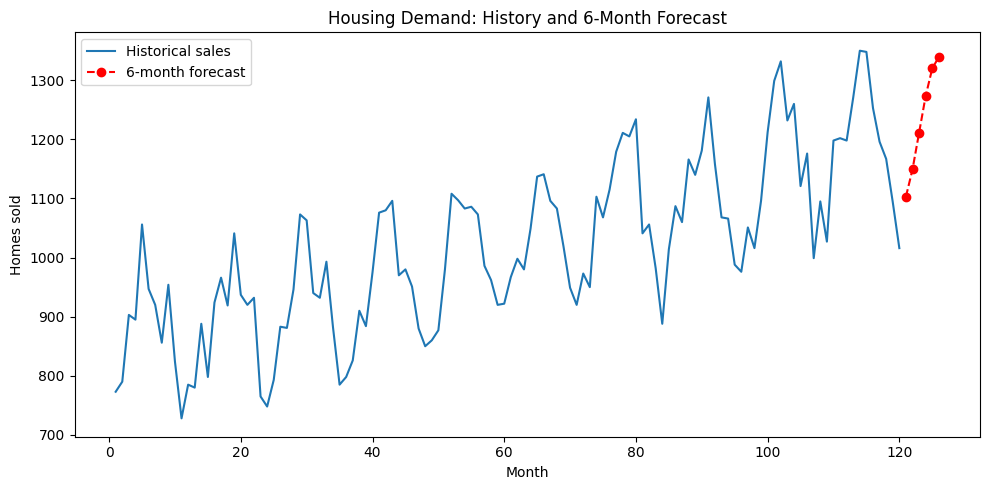


Saved chart to demand_forecast.png

Assumptions:
- Past trend and seasonality continue; no shocks (rate spikes, new inventory).
- One region aggregated together; demand = closed sales.

Challenges:
- Plain linear regression on month alone flatlines through the seasonal
  swings; the sine/cosine terms were needed to track the spring/winter cycle.
- A single straight-line trend over 10 years can hide regime changes
  (the 2020-2022 rate environment did not behave like 2015).

Potential improvements:
- Add drivers: mortgage rates, active listings, median price.
- Try models built for time series (SARIMA, Prophet, gradient boosting).
- Use a holdout of the last 6 months to validate forecast error before trusting it.



In [5]:
# Extra Credit: Housing Demand Forecasting
# Author: Cash Johnson
#
# Data source: housing_demand.csv (120 monthly records). AI-generated per the
# instructor's Module 3 dataset instructions, shaped like Santa Clara County
# monthly home-sales trends (spring peak, winter dip, mild long-run growth).
# See generate_datasets.py in this repo for exactly how it was built.
#
# Changes from starter code:
# - 120 months (10 years) of data loaded from CSV instead of a tiny sample
# - Added a month-of-year seasonality feature on top of the linear trend,
#   because housing demand is strongly seasonal and a straight line misses it
# - Forecast printed as a table and saved to a labeled chart (demand_forecast.png)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load and preprocess
df = load('housing_demand.csv')  # columns: month (1..N), sales
df = df.dropna().sort_values('month')
print(f"Loaded {len(df)} months of sales data from housing_demand.csv\n")

# Feature engineering: linear trend + sine/cosine terms for annual seasonality
def make_features(months):
    m = np.asarray(months, dtype=float)
    return np.column_stack([
        m,                                # long-run trend
        np.sin(2 * np.pi * m / 12),       # yearly cycle
        np.cos(2 * np.pi * m / 12),
    ])

X = make_features(df['month'])
y = df['sales']

model = LinearRegression()
model.fit(X, y)
print(f"In-sample R^2: {model.score(X, y):.3f}")
print(f"Trend coefficient: {model.coef_[0]:+.2f} sales per month "
      "(the market is slowly growing)\n")

# Forecast the next 6 months
last = int(df['month'].max())
future_months = np.arange(last + 1, last + 7)
predictions = model.predict(make_features(future_months))

print("6-month forecast:")
for m, p in zip(future_months, predictions):
    print(f"  Month {m}: {p:,.0f} homes")

# Visualize
plt.figure(figsize=(10, 5))
plt.plot(df['month'], y, label='Historical sales')
plt.plot(future_months, predictions, 'r--o', label='6-month forecast')
plt.xlabel('Month')
plt.ylabel('Homes sold')
plt.title('Housing Demand: History and 6-Month Forecast')
plt.legend()
plt.tight_layout()
plt.savefig('demand_forecast.png')
plt.show()
print("\nSaved chart to demand_forecast.png")

print("""
Assumptions:
- Past trend and seasonality continue; no shocks (rate spikes, new inventory).
- One region aggregated together; demand = closed sales.

Challenges:
- Plain linear regression on month alone flatlines through the seasonal
  swings; the sine/cosine terms were needed to track the spring/winter cycle.
- A single straight-line trend over 10 years can hide regime changes
  (the 2020-2022 rate environment did not behave like 2015).

Potential improvements:
- Add drivers: mortgage rates, active listings, median price.
- Try models built for time series (SARIMA, Prophet, gradient boosting).
- Use a holdout of the last 6 months to validate forecast error before trusting it.
""")
